# House Prices — Step 6: Train a Model on Each Encoding & Compare

We now train the **same model** (Random Forest Regressor) on each of the four encoded versions of the dataset, predict `SalePrice` on a held-out test split, and compare performance.

`SalePrice` is a continuous number, so this is a **regression** problem, not classification — there's no "% correct" accuracy. Instead we use two standard regression metrics:

- **RMSE (Root Mean Squared Error)** — the average prediction error, in dollars. Lower is better.
- **R² (R-squared)** — the proportion of price variation the model explains (1.0 = perfect, 0 = no better than guessing the average). Higher is better.

We use the **same train/test split (same row indices)** across all four datasets, so any performance difference reflects the encoding method, not random chance.

## 1. Load the four encoded datasets

All four were built from the same cleaned data and kept the same row order, so we can safely apply one shared train/test split across all of them.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

datasets = {
    'Label Encoding': pd.read_csv('train_label_encoded.csv'),
    'One-Hot Encoding': pd.read_csv('train_onehot_encoded.csv'),
    'Target Encoding (plain)': pd.read_csv('train_target_encoded.csv'),
    'K-Fold Target Encoding': pd.read_csv('train_kfold_target_encoded.csv'),
}

for name, d in datasets.items():
    print(f"{name}: {d.shape}")

Label Encoding: (1460, 81)
One-Hot Encoding: (1460, 246)
Target Encoding (plain): (1460, 81)
K-Fold Target Encoding: (1460, 81)


## 2. Create one shared train/test split

We split on row position (80% train / 20% test) using a fixed `random_state`, then reuse the exact same row indices for every dataset — this keeps the comparison fair.

In [2]:
n_rows = len(datasets['Label Encoding'])
all_idx = np.arange(n_rows)
train_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=42)

print(f"Train rows: {len(train_idx)}, Test rows: {len(test_idx)}")

Train rows: 1168, Test rows: 292


## 3. Train a Random Forest on each dataset and evaluate

For each encoded dataset, we:
1. Split into features (`X`, everything except `Id` and `SalePrice`) and target (`y`, `SalePrice`)
2. Apply the shared train/test indices
3. Fit a `RandomForestRegressor`
4. Predict on the test rows and compute RMSE and R²

In [3]:
results = {}
predictions = {}

for name, d in datasets.items():
    X = d.drop(columns=['SalePrice', 'Id'], errors='ignore')
    y = d['SalePrice']

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'R2': r2}
    predictions[name] = (y_test.values, y_pred)

    print(f"{name:28s}  RMSE: {rmse:>10,.0f}   R2: {r2:.4f}")

Label Encoding                RMSE:     28,247   R2: 0.8960


One-Hot Encoding              RMSE:     28,575   R2: 0.8935


Target Encoding (plain)       RMSE:     28,390   R2: 0.8949


K-Fold Target Encoding        RMSE:     29,536   R2: 0.8863


## 4. Comparison table and the best-performing encoding

We rank the four encodings by RMSE (lower = better) and highlight the winner.

**Expected pattern to watch for:** plain Target Encoding was built using each row's own `SalePrice` (Step 4's leakage), so it may look unrealistically strong here — its test rows still carry information from their own target. K-Fold Target Encoding removes that leakage, so it's the more trustworthy number of the two, even if plain Target Encoding shows a lower RMSE in this comparison.

In [4]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
results_df.insert(0, 'Rank', range(1, len(results_df) + 1))
print(results_df.to_string(float_format=lambda x: f'{x:,.4f}'))

best_encoding = results_df.index[0]
print(f"\nBest encoding by RMSE: {best_encoding}")
print(f"RMSE: {results_df.loc[best_encoding, 'RMSE']:,.0f}   R2: {results_df.loc[best_encoding, 'R2']:.4f}")

                         Rank        RMSE     R2
Label Encoding              1 28,246.7299 0.8960
Target Encoding (plain)     2 28,390.1439 0.8949
One-Hot Encoding            3 28,575.4254 0.8935
K-Fold Target Encoding      4 29,535.7603 0.8863

Best encoding by RMSE: Label Encoding
RMSE: 28,247   R2: 0.8960


## 5. Visualize the comparison

A simple bar chart of RMSE across the four encodings, and a scatter plot of predicted vs. actual `SalePrice` for the best-performing encoding.

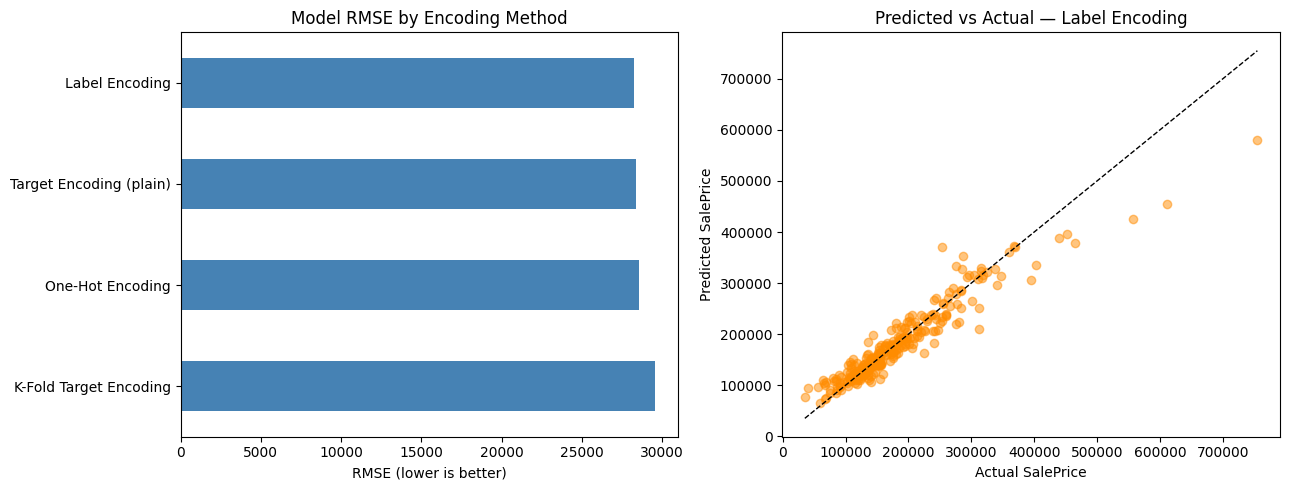

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE bar chart
results_df['RMSE'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('Model RMSE by Encoding Method')
axes[0].invert_yaxis()

# Predicted vs actual for the best encoding
y_test_best, y_pred_best = predictions[best_encoding]
axes[1].scatter(y_test_best, y_pred_best, alpha=0.5, color='darkorange')
lims = [min(y_test_best.min(), y_pred_best.min()), max(y_test_best.max(), y_pred_best.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlabel('Actual SalePrice')
axes[1].set_ylabel('Predicted SalePrice')
axes[1].set_title(f'Predicted vs Actual — {best_encoding}')

plt.tight_layout()
plt.savefig('encoding_comparison.png', dpi=100)
plt.show()

## 6. Save the comparison results

Saved as a CSV for reference alongside the encoded datasets from the previous steps.

In [6]:
results_df.to_csv('encoding_comparison_results.csv')
print("Saved encoding_comparison_results.csv")
results_df

Saved encoding_comparison_results.csv


,Rank,RMSE,R2
Label Encoding,1,28246.729919,0.895979
Target Encoding (plain),2,28390.143947,0.894920
One-Hot Encoding,3,28575.425438,0.893544
K-Fold Target Encoding,4,29535.760267,0.886268
